# 04 - Embedding + Batched Inputs Basics

Three progressive examples with batched embedding input:
1. 1D function regression (easy)
2. 2D linear binary classification
3. XOR classification (nonlinear)

All examples optimize only `thetas` and feed data through `embedding` in shape `(B, N_embedding)`.

- **EN** Circuits are built with the `Circuit` builder: `qc = Circuit(n_qubits=...)`, gates via `qc.rx(q, embedding_idx=k)` (data-driven, from `x[k]`) or `qc.rx(q, param_idx=i)` (trainable, from `thetas[i]`), then `qc.compile(observables=..., preset=...)` once and `qc.expvals(thetas, embedding=x_batch)` many times.
- **KO** 회로는 `Circuit` 빌더로 만듭니다: `qc = Circuit(n_qubits=...)`, 게이트는 `qc.rx(q, embedding_idx=k)`(데이터 기반, `x[k]`에서 값을 가져옴) 또는 `qc.rx(q, param_idx=i)`(학습 가능, `thetas[i]`에서 값을 가져옴)로 추가하고, `qc.compile(observables=..., preset=...)`을 한 번 호출한 뒤 `qc.expvals(thetas, embedding=x_batch)`를 여러 번 호출합니다.


In [1]:
# EN: Setup for embedding/batching examples. We import plotting tools as well because later sections visualize fit quality.
# KO: embedding/batch 예제를 위한 초기 설정입니다. 뒤에서 학습 결과를 시각화하므로 plotting 도구도 같이 불러옵니다.

import warnings
warnings.filterwarnings("ignore")

import torch
import matplotlib.pyplot as plt

from padopauli import Circuit

if not torch.cuda.is_available():
    raise RuntimeError('This notebook is configured for GPU-only execution, but CUDA is not available.')

torch.manual_seed(0)
device = 'cuda'
dtype = torch.float64

In [2]:
def model_scalar(qc, thetas, embedding):
    out = qc.expvals(thetas, embedding=embedding)
    return out[:, 0]

def expv_to_prob(expv):
    expv = torch.nan_to_num(expv, nan=0.0, posinf=1.0, neginf=-1.0)
    return torch.clamp((expv + 1.0) * 0.5, 1e-5, 1.0 - 1e-5)

## 1) 1D function regression (easy)
Fit $y=\sin(x)$ with one embedded feature.

propagate:   0%|          | 0/2 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 2


zero-filter:   0%|          | 0/2 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 1 (50.000000% of peak)


Initial parameter: [0.]


0th parameter: [-0.05]
1D step 0, MSE: 1.000000


80th parameter: [-1.55402182]
1D step 80, MSE: 0.000119


160th parameter: [-1.57078794]
1D step 160, MSE: 0.000000


240th parameter: [-1.57079129]
1D step 240, MSE: 0.000000


320th parameter: [-1.57079635]
1D step 320, MSE: 0.000000
1D final MSE: 6.95225774543329e-19


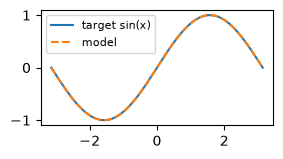

In [3]:
# Use phase-shift form:
# RX(x_embed) -> RX(theta)
# then <Z> = cos(x + theta), which can represent sin(x) exactly because sin(x) = cos(x - pi/2)

qc_1d = Circuit(n_qubits=1)
qc_1d.rx(0, embedding_idx=0)
qc_1d.rx(0, param_idx=0)
qc_1d.compile(observables=[('Z', [0])], preset='gpu')

x = torch.linspace(-3.14159, 3.14159, 128, dtype=dtype, device=device).unsqueeze(1) # (128, 1) -> recognized as (batch, 1)
y = torch.sin(x[:, 0]) # (128,) - make sure target shape matches model output shape for MSE loss

thetas_1d = torch.nn.Parameter(torch.tensor([0.0], dtype=dtype, device=device))
opt_1d = torch.optim.Adam([thetas_1d], lr=0.05)
losses_1d = []

print(f"Initial parameter: {thetas_1d.detach().cpu().numpy()}")
for i in range(400):
    opt_1d.zero_grad(set_to_none=True)
    pred = model_scalar(qc_1d, thetas_1d, x) # x = embedding_batch
    loss = torch.mean((pred - y) ** 2)
    loss.backward()
    opt_1d.step()
    losses_1d.append(float(loss.detach()))

    if i % 80 == 0:
        print(f"{i}th parameter: {thetas_1d.detach().cpu().numpy()}")
        print(f"1D step {i}, MSE: {losses_1d[-1]:.6f}")

print('1D final MSE:', losses_1d[-1])

with torch.no_grad():
    y_hat = model_scalar(qc_1d, thetas_1d, x)

plt.figure(figsize=(3.0, 1.5))
plt.plot(x[:, 0].cpu(), y.cpu(), label='target sin(x)')
plt.plot(x[:, 0].cpu(), y_hat.cpu(), '--', label='model')
plt.legend(loc='upper left', fontsize=8)
import os as _os; _os.makedirs("figures", exist_ok=True); plt.savefig("figures/fig_sin_regression.png", dpi=150, bbox_inches="tight")
plt.show()

## 2) 2D linear binary classification
Use $(x_1, x_2)$ as batched embedding input `(B,2)` and train only `thetas`.

In [4]:
# 2D linear dataset (keep range small to avoid periodic wrap-around issues)
n = 1024
X2 = (torch.rand(n, 2, dtype=dtype, device=device) * 2.0 - 1.0) * 1.2 # (0, 1) -> (-1, 1) scaled to (-1.2, 1.2)
y2 = ((X2[:, 0] + X2[:, 1]) > 0).to(dtype)

# Feature map matched to linear boundary:
# RY(x1) -> RY(x2) -> RY(theta) on one qubit gives angle (x1 + x2 + theta)
# Measure Z so output is cos(x1 + x2 + theta), whose sign gives a linear separator.
qc_2d = Circuit(n_qubits=1)
qc_2d.ry(0, embedding_idx=0)
qc_2d.ry(0, embedding_idx=1)
qc_2d.ry(0, param_idx=0)
qc_2d.compile(observables=[('Z', [0])], preset='gpu')

thetas_2d = torch.nn.Parameter(torch.tensor([0.0], dtype=dtype, device=device))
opt_2d = torch.optim.Adam([thetas_2d], lr=0.03)
batch_size = 128

for epoch in range(180):
    perm = torch.randperm(n, device=device)
    for s in range(0, n, batch_size):
        idx = perm[s:s + batch_size]
        xb = X2[idx]
        yb = y2[idx]

        opt_2d.zero_grad(set_to_none=True)
        expv = model_scalar(qc_2d, thetas_2d, xb)
        prob = expv_to_prob(expv)
        loss = torch.nn.functional.binary_cross_entropy(prob, yb)

        if not torch.isfinite(loss): # skip this batch if the loss is NaN/Inf
            continue

        loss.backward()

        if thetas_2d.grad is None or (not torch.isfinite(thetas_2d.grad).all()): # skip the update if the gradient is NaN/Inf
            opt_2d.zero_grad(set_to_none=True)
            continue

        torch.nn.utils.clip_grad_norm_([thetas_2d], max_norm=5.0) # clip the gradient L2 norm to 5.0
        opt_2d.step()

        with torch.no_grad():
            thetas_2d.data = torch.nan_to_num(thetas_2d.data, nan=0.0, posinf=0.0, neginf=0.0)

    if epoch % 30 == 0:
        with torch.no_grad():
            p_eval = expv_to_prob(model_scalar(qc_2d, thetas_2d, X2))
            acc_eval = ((p_eval >= 0.5).to(dtype) == y2).to(dtype).mean().item()
        print(f'2D epoch {epoch:3d} | loss {float(loss.detach()):.4f} | acc {acc_eval:.4f}')

with torch.no_grad():
    p_all = expv_to_prob(model_scalar(qc_2d, thetas_2d, X2))
    acc2 = ((p_all >= 0.5).to(dtype) == y2).to(dtype).mean().item()

print('2D linear classification accuracy:', acc2)
print('learned theta:', thetas_2d.detach().cpu().numpy())

propagate:   0%|          | 0/3 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 2


zero-filter:   0%|          | 0/3 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 1 (50.000000% of peak)
2D epoch   0 | loss 1.0692 | acc 0.5615


2D epoch  30 | loss 0.2447 | acc 0.9961


2D epoch  60 | loss 0.2349 | acc 0.9961


2D epoch  90 | loss 0.2514 | acc 0.9961


2D epoch 120 | loss 0.2438 | acc 0.9961


2D epoch 150 | loss 0.2156 | acc 0.9971


2D linear classification accuracy: 0.9970703125
learned theta: [-1.55548671]


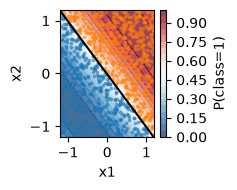

In [5]:
# 2D classification visualization (probability field + labeled samples)
grid_lin = torch.linspace(-1.2, 1.2, 180, dtype=dtype, device=device)
gx, gy = torch.meshgrid(grid_lin, grid_lin, indexing='xy')
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1) # (num_points, 2)

with torch.no_grad():
    p_grid = expv_to_prob(model_scalar(qc_2d, thetas_2d, grid))
p_img = p_grid.reshape(gx.shape).cpu().numpy()
levels = torch.linspace(0.0, 1.0, 21).cpu().numpy()

plt.figure(figsize=(2.5, 2.0))
cf = plt.contourf(gx.cpu().numpy(), gy.cpu().numpy(), p_img, levels=levels, cmap='RdBu_r', alpha=0.75) # filled probability field
plt.contour(gx.cpu().numpy(), gy.cpu().numpy(), p_img, levels=[0.5], colors='k', linewidths=1.5)
plt.colorbar(cf, label='P(class=1)')

X2_np = X2.cpu().numpy()
y2_np = y2.cpu().numpy()
plt.scatter(X2_np[y2_np < 0.5, 0], X2_np[y2_np < 0.5, 1], s=3, alpha=0.5, label='class 0')
plt.scatter(X2_np[y2_np >= 0.5, 0], X2_np[y2_np >= 0.5, 1], s=3, alpha=0.5, label='class 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()
import os as _os; _os.makedirs("figures", exist_ok=True); plt.savefig("figures/fig_class_linear.png", dpi=150, bbox_inches="tight")
plt.show()

## 3) XOR classification (nonlinear)
Shows a harder nonlinearly separable task.

In [6]:
n_xor = 512
Xx = (torch.rand(n_xor, 2, dtype=dtype, device=device) * 2.0 - 1.0) * 3.14159 # (0,1) -> (-1, 1) -> (-pi, pi)
yx = ((Xx[:, 0] * Xx[:, 1]) < 0).to(dtype) # XOR labels

qc_xor = Circuit(n_qubits=2)
qc_xor.rx(0, embedding_idx=0)
qc_xor.rx(1, embedding_idx=1)
qc_xor.cnot(0, 1)
qc_xor.ry(0, param_idx=0)
qc_xor.ry(1, param_idx=1)
qc_xor.cnot(1, 0)
qc_xor.rz(0, param_idx=2)
qc_xor.compile(observables=[('Z', [0])], preset='gpu')

thetas_xor = torch.nn.Parameter(torch.randn(3, dtype=dtype, device=device) * 0.1) # trainable parameters
opt_xor = torch.optim.Adam([thetas_xor], lr=0.03)

for epoch in range(320):
    perm = torch.randperm(n_xor, device=device)
    for s in range(0, n_xor, batch_size):
        idx = perm[s:s + batch_size]
        xb = Xx[idx]
        yb = yx[idx]

        opt_xor.zero_grad(set_to_none=True)
        expv = model_scalar(qc_xor, thetas_xor, xb)
        prob = expv_to_prob(expv)
        loss = torch.nn.functional.binary_cross_entropy(prob, yb)

        if not torch.isfinite(loss):
            continue

        loss.backward()

        if thetas_xor.grad is None or (not torch.isfinite(thetas_xor.grad).all()):
            opt_xor.zero_grad(set_to_none=True)
            continue

        torch.nn.utils.clip_grad_norm_([thetas_xor], max_norm=5.0)
        opt_xor.step()

        with torch.no_grad():
            thetas_xor.data = torch.nan_to_num(thetas_xor.data, nan=0.0, posinf=0.0, neginf=0.0)

    if epoch % 40 == 0:
        with torch.no_grad():
            p_eval = expv_to_prob(model_scalar(qc_xor, thetas_xor, Xx))
            acc_eval = ((p_eval >= 0.5).to(dtype) == yx).to(dtype).mean().item()
        print(f'XOR epoch {epoch:3d} | loss {float(loss.detach()):.4f} | acc {acc_eval:.4f}')

with torch.no_grad():
    p_xor = expv_to_prob(model_scalar(qc_xor, thetas_xor, Xx))
    acc_xor = ((p_xor >= 0.5).to(dtype) == yx).to(dtype).mean().item()
print('XOR classification accuracy:', acc_xor)

propagate:   0%|          | 0/7 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 9


zero-filter:   0%|          | 0/7 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 2 (22.222222% of peak)
XOR epoch   0 | loss 1.4254 | acc 0.4980


XOR epoch  40 | loss 0.3798 | acc 0.9492


...

XOR epoch 160 | loss 0.3968 | acc 0.9492


XOR epoch 200 | loss 0.3760 | acc 0.9492


XOR epoch 240 | loss 0.3542 | acc 0.9492


XOR epoch 280 | loss 0.3465 | acc 0.9688


XOR classification accuracy: 0.94921875


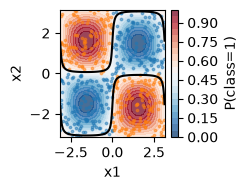

In [7]:
# XOR classification visualization (probability field + labeled samples)
grid_lin = torch.linspace(-3.14159, 3.14159, 220, dtype=dtype, device=device)
gx, gy = torch.meshgrid(grid_lin, grid_lin, indexing='xy')
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)

# evaluate the grid in chunks to bound memory
chunk_size = 4096
p_parts = []
with torch.no_grad():
    for s in range(0, grid.shape[0], chunk_size):
        gb = grid[s:s + chunk_size]
        p_parts.append(expv_to_prob(model_scalar(qc_xor, thetas_xor, gb)))
    p_grid = torch.cat(p_parts, dim=0)
    if device == 'cuda':
        torch.cuda.synchronize()

p_img = p_grid.reshape(gx.shape).detach().cpu().numpy()
levels = torch.linspace(0.0, 1.0, 21).cpu().numpy()

plt.figure(figsize=(2.5, 2.0))
cf = plt.contourf(gx.cpu().numpy(), gy.cpu().numpy(), p_img, levels=levels, cmap='RdBu_r', alpha=0.75)
plt.contour(gx.cpu().numpy(), gy.cpu().numpy(), p_img, levels=[0.5], colors='k', linewidths=1.5)
plt.colorbar(cf, label='P(class=1)')

Xx_np = Xx.cpu().numpy()
yx_np = yx.cpu().numpy()
plt.scatter(Xx_np[yx_np < 0.5, 0], Xx_np[yx_np < 0.5, 1], s=3, alpha=0.5, label='class 0')
plt.scatter(Xx_np[yx_np >= 0.5, 0], Xx_np[yx_np >= 0.5, 1], s=3, alpha=0.5, label='class 1')

plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()
import os as _os; _os.makedirs("figures", exist_ok=True); plt.savefig("figures/fig_class_xor.png", dpi=150, bbox_inches="tight")
plt.show()

## Notes
- Inputs are batched with `embedding` shape `(B, N_embedding)`; each circuit's minimum embedding length is `qc.n_embedding` (e.g. `qc_2d.n_embedding == 2`).
- Trainable parameters are only `thetas`, of minimum length `qc.n_params` (e.g. `qc_xor.n_params == 3`).
- `qc.expvals(thetas, embedding=embedding)` outer-products the parameter batch and the embedding batch: shape `(N_obs,)` for unbatched inputs, `(p_bs, N_obs)` when only one of thetas/embedding is batched, `(e_bs, p_bs, N_obs)` when both are batched. Here `thetas` is always unbatched, so the output is `(B, N_obs)` and `model_scalar` takes column 0.
- All three circuits above use `preset='gpu'` and `device='cuda'`; this notebook requires a GPU (the setup cell stops otherwise).